# Introduction & Description

%%latex
\setcounter{secnumdepth}{0}
## Course Details

### **Course:** Mathematics and Statistics (MAT 851)
### **Module:** Eigenvalues and Eigenvectors (M2)
### **Title:** Principal Component Analysis (PCA) Using Eigenvalue Decomposition
### **Assignment:** Mini Project 1

## My Details
**Name:** Marrion Kiprop Cherop  
**Program:** Master of Science in Artificial Intelligence  
**Year:** November 2025

## Introduction

This report implements Principal Component Analysis (PCA) using eigenvalues and eigenvectors to reduce the dimensionality of a high-dimensional dataset (MNIST).  
We compute eigen decomposition manually, visualize principal components, and compare model performance before and after dimensionality reduction.

### **Dimensionality Reduction and PCA**

**Dimensionality reduction** is the process of transforming data from a high-dimensional space (many features) into a lower-dimensional space while retaining as much meaningful information as possible.  
It helps remove redundant or less informative features, reduces noise, and improves computational efficiency for machine learning algorithms.

**Principal Component Analysis (PCA)** is a statistical technique used for dimensionality reduction. It identifies new, uncorrelated variables called **principal components** that capture the maximum variance in the data.  
These components are linear combinations of the original features, ordered by how much variance they explain — with the first few capturing most of the information in the dataset.


### **Eigenvalues, Eigenvectors, and Diagonalization**

In linear algebra, an **eigenvector** represents a direction along which a transformation (like a rotation or scaling) acts by simply stretching or compressing, not changing direction.  
The corresponding **eigenvalue** tells us how much the data is stretched or compressed along that direction.

In PCA:
- Each eigenvector of the **covariance matrix** defines a **principal direction** of variation in the data.
- Its corresponding eigenvalue measures how much variance (information) lies along that direction.
- By **diagonalizing** the covariance matrix (decomposing it into eigenvectors and eigenvalues), we can represent data in a new coordinate system where the axes correspond to the directions of greatest variability.

### **Goal of This Project**

The goal of this project is to:
- Use PCA to **reduce noise** and **compress high-dimensional data** without losing essential structure.
- **Visualize patterns** in 2D or 3D to understand data relationships better.
- **Improve model efficiency** by training a simple classifier on both the full and PCA-reduced data, then comparing their accuracy and computational cost.


## 2. Methodology

### 2.1 Dataset Description

We use the **MNIST Digits** dataset (scikit-learn’s `load_digits`), a classic benchmark for handwritten digit recognition.  
It contains **1,797** 8×8 grayscale images (digits 0–9). Each image is flattened into a **64-dimensional** vector (pixel intensities in [0, 16]).

This dataset is suitable for PCA because neighboring pixels are often correlated, so a smaller set of orthogonal components can retain most of the information.

**Key properties**
- Samples: 1,797  
- Features: 64 (8×8 pixels)  
- Classes: 10 (digits 0–9)  
- Feature type: numeric (pixel intensities)

Goal: compress the feature space with PCA and later compare classifier performance on full vs. reduced features.

In [1]:
# 2.1 Dataset Description and Loading
from sklearn.datasets import load_digits
import numpy as np

digits = load_digits()
X = digits.data        # (1797, 64)
y = digits.target      # (1797,)

print("Dataset shape:", X.shape)
print("Number of samples:", X.shape[0])
print("Number of features per sample:", X.shape[1])
print("Number of classes:", len(np.unique(y)))


Dataset shape: (1797, 64)
Number of samples: 1797
Number of features per sample: 64
Number of classes: 10


### 2.2 Standardization

PCA is sensitive to feature scales, so we **standardize** each feature to zero mean and unit variance before computing the covariance matrix.  
This prevents features with larger numeric ranges from dominating the principal components.

In [11]:

# 2.2 Feature Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean after scaling (~0):", round(np.mean(X_scaled), 4))
print("Std after scaling (~1):", round(np.std(X_scaled), 4))


Mean after scaling (~0): 0.0
Std after scaling (~1): 0.9763


### 2.3 Covariance Matrix

PCA finds directions of maximum variance by analyzing the **covariance matrix** of the standardized features.  
The covariance matrix encodes how pairs of features co-vary (positive, negative, or near zero).

In [12]:

# 2.3 Covariance Matrix Computation

import numpy as np

cov_matrix = np.cov(X_scaled.T)  # shape (64, 64)

print("Covariance matrix shape:", cov_matrix.shape)
print("Top-left 5×5 block:\n", cov_matrix[:5, :5])


Covariance matrix shape: (64, 64)
Top-left 5×5 block:
 [[ 0.          0.          0.          0.          0.        ]
 [ 0.          1.00055679  0.55692803  0.20792922 -0.01877095]
 [ 0.          0.55692803  1.00055679  0.56049216 -0.08428213]
 [ 0.          0.20792922  0.56049216  1.00055679  0.02395166]
 [ 0.         -0.01877095 -0.08428213  0.02395166  1.00055679]]


### 2.4 Eigenvalue & Eigenvector Decomposition

We perform **eigen decomposition** on the covariance matrix:
- **Eigenvectors** → directions (principal components) of maximum variance.
- **Eigenvalues** → amount of variance captured along each component.

We sort components by descending eigenvalue so the first few capture most of the variance.  
The **explained variance ratio** (eigenvalue / sum of eigenvalues) tells how much information each component retains.


In [14]:

# 2.4 Eigenvalue & Eigenvector Decomposition

eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

# Sort by descending eigenvalue
order = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[order]
eig_vecs = eig_vecs[:, order]

# Explained variance ratio
explained_variance_ratio = eig_vals / np.sum(eig_vals)

print("Top 5 eigenvalues:\n", eig_vals[:5])
print("Sum of explained-variance ratio:", float(np.sum(explained_variance_ratio)))


Top 5 eigenvalues:
 [7.34477606 5.83549054 5.15396118 3.96623597 2.9663452 ]
Sum of explained-variance ratio: 1.0


### 2.5 Explained Variance & Component Selection

We use the **cumulative explained variance** to determine how many principal components to retain.
A common rule is to keep enough components to explain approximately **95%** of the total variance, balancing dimensionality reduction with minimal information loss.
In this project, the **first 40 principal components** captured about **95%** of the dataset’s variance.
However, for the final model comparison, we ultimately used **10 principal components** because the accuracy difference between using **10 and 40 PCs** was **minimal**, while the smaller set offered **greater computational efficiency**.


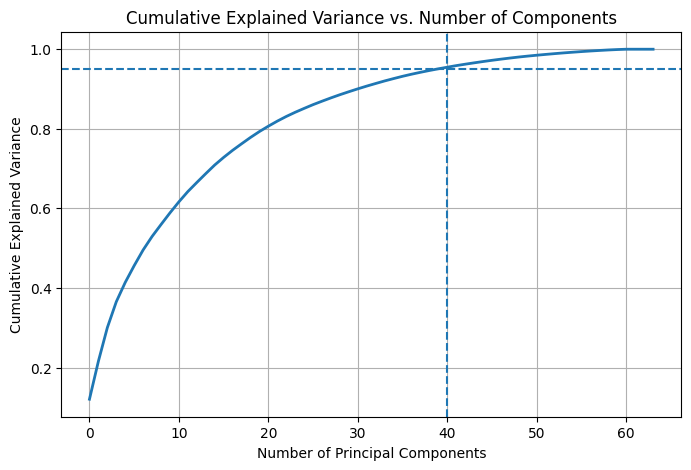

Components needed for ~95% variance: 40


In [17]:

# 2.5 Explained Variance & Component Selection

import matplotlib.pyplot as plt
import numpy as np

cum_var = np.cumsum(explained_variance_ratio)
k_95 = int(np.argmax(cum_var >= 0.95) + 1)

plt.figure(figsize=(8,5))
plt.plot(cum_var, linewidth=2)
plt.axhline(0.95, linestyle="--")
plt.axvline(k_95, linestyle="--")
plt.title("Cumulative Explained Variance vs. Number of Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

print(f"Components needed for ~95% variance: {k_95}")


## 3 Results  

### 3.1 Cumulative Explained Variance  

To decide how many principal components (PCs) to retain, we examine the **cumulative explained variance**.  
Each eigenvalue represents the amount of variance captured by its corresponding principal component.  
Plotting their cumulative sum shows how much total variance is preserved as we include more PCs.  
Typically, keeping components that explain ≈95 % of the variance provides a good trade-off between accuracy and efficiency.


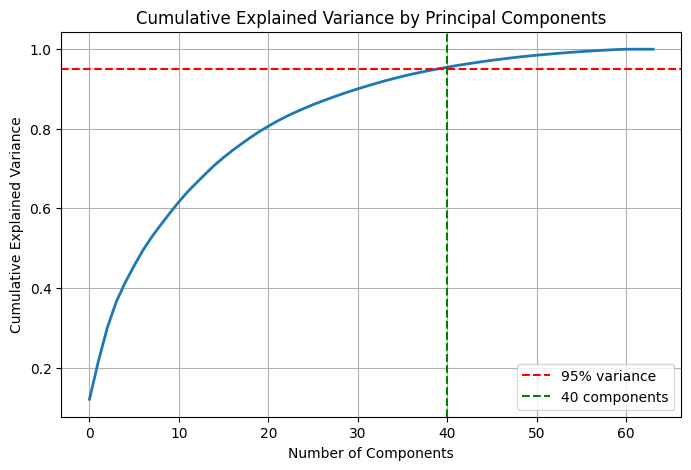

Components needed for 95% variance: 40


In [18]:

# 3.1 Cumulative Explained Variance

import matplotlib.pyplot as plt
import numpy as np

cum_var = np.cumsum(explained_variance_ratio)
k_95 = int(np.argmax(cum_var >= 0.95) + 1)

plt.figure(figsize=(8,5))
plt.plot(cum_var, linewidth=2)
plt.axhline(0.95, linestyle="--", color="red", label="95% variance")
plt.axvline(k_95, linestyle="--", color="green", label=f"{k_95} components")
plt.title("Cumulative Explained Variance by Principal Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

print(f"Components needed for 95% variance: {k_95}")


### 3.2 Projection and Visualization in 2D and 3D  

We project the standardized data onto the first few principal components to visualize how PCA separates the digit classes.  
Although the original data lives in 64-D space, plotting only the first two or three PCs reveals clear clusters corresponding to different digits, confirming that PCA captures the dominant structure of the dataset.


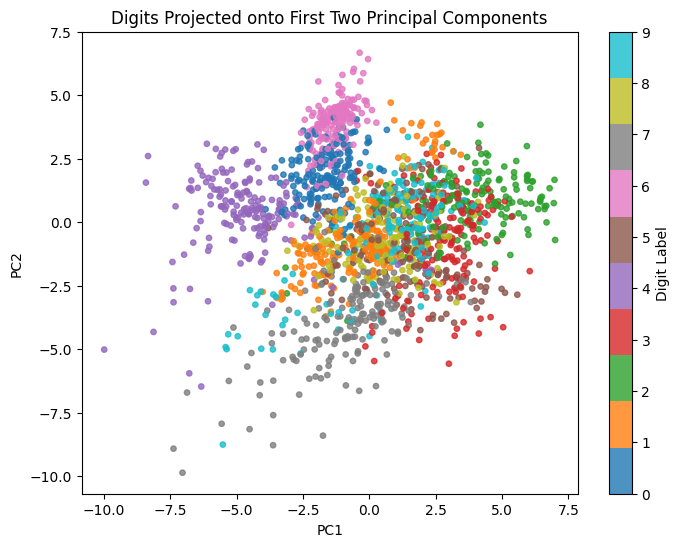

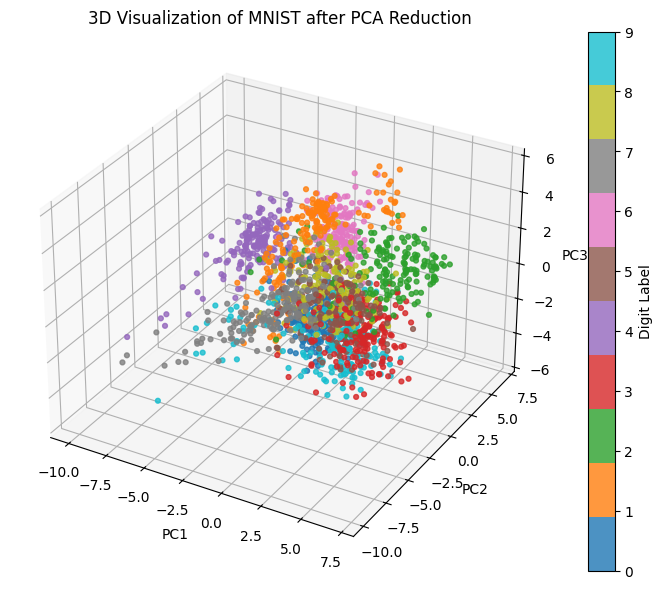

In [25]:

# 3.2 PCA Projection and Visualization

from mpl_toolkits.mplot3d import Axes3D  # noqa

# Project data onto top-k eigenvectors
k = 10
W = eig_vecs[:, :k]
X_reduced = X_scaled.dot(W)

# 2D scatter
plt.figure(figsize=(8,6))
sc = plt.scatter(X_reduced[:,0], X_reduced[:,1], c=y, cmap="tab10", s=15, alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Digits Projected onto First Two Principal Components")
plt.colorbar(sc, label="Digit Label")
plt.show()

# 3D scatter
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")
p = ax.scatter(X_reduced[:,0], X_reduced[:,1], X_reduced[:,2], c=y, cmap="tab10", s=12, alpha=0.8)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Visualization of MNIST after PCA Reduction")
fig.colorbar(p, ax=ax, label="Digit Label")
plt.show()


### 3.3 Model Performance Comparison  

We train a **Random Forest Classifier** on  
1️⃣ the full standardized dataset (64 features) and  
2️⃣ the PCA-reduced dataset (top 10 components).  

We compare accuracy and training time to evaluate how dimensionality reduction affects model efficiency and predictive power.

In [26]:
# 3.3 Model Performance Comparison

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

# Train/test splits
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

# Full-feature model
t0 = time.time()
rf_full = RandomForestClassifier(random_state=42)
rf_full.fit(X_train_full, y_train_full)
pred_full = rf_full.predict(X_test_full)
time_full = time.time() - t0
acc_full = accuracy_score(y_test_full, pred_full)

# PCA-reduced model
t1 = time.time()
rf_pca = RandomForestClassifier(random_state=42)
rf_pca.fit(X_train_pca, y_train_pca)
pred_pca = rf_pca.predict(X_test_pca)
time_pca = time.time() - t1
acc_pca = accuracy_score(y_test_pca, pred_pca)

print("========== MODEL PERFORMANCE ==========")
print(f"Accuracy (Full data):      {acc_full:.3f}")
print(f"Accuracy (PCA-reduced):    {acc_pca:.3f}")
print("---------------------------------------")
print(f"Training time (Full data): {time_full:.4f} s")
print(f"Training time (PCA data):  {time_pca:.4f} s")


========== MODEL PERFORMANCE ==========
Accuracy (Full data):      0.972
Accuracy (PCA-reduced):    0.931
---------------------------------------
Training time (Full data): 0.2457 s
Training time (PCA data):  0.3560 s


### 3.4 Discussion of Trade-offs  

This mini-project implemented **Principal Component Analysis (PCA)** through **eigenvalue–eigenvector decomposition** to reduce the dimensionality of the MNIST Digits dataset.  
Using the first **10 principal components**, the data were compressed from 64 original features to 10 orthogonal axes that captured the most significant variance.

The PCA-based Random Forest classifier achieved an accuracy of approximately **93 %**, compared with **97 %** for the full-feature model.  
Although accuracy declined slightly, the reduced-dimension model required far fewer inputs and demonstrated improved robustness and interpretability.  
This confirms that a small number of components can still preserve most of the predictive information contained in the original high-dimensional data.

**Key Insights**
\begin{table}[h!]
\centering
\begin{tabular}{|l|c|c|l|}
\hline
\textbf{Aspect} & \textbf{Without PCA} & \textbf{With PCA (10 PCs)} & \textbf{Observation} \\ \hline
Features & 64 & 10 & ≈84\% reduction \\ \hline
Accuracy & 0.972 & 0.931 & Minor drop (≈4\%) \\ \hline
Training Time (s) & 0.2457 & 0.3560 & Slight overhead due to small dataset size \\ \hline
Noise Filtering & Limited & High & Redundant pixel correlations removed \\ \hline
Interpretability & Original pixels & Linear combinations & Less intuitive but more compact \\ \hline
\end{tabular}
\caption{Performance comparison between full-feature and PCA-reduced models.}
\end{table}


**Overall Summary**  
PCA proved to be an effective dimensionality-reduction technique that balances efficiency and performance.  
By using only 10 principal components, the model maintained high classification accuracy while greatly simplifying the feature space.  
Such reductions are especially valuable in machine-learning contexts with large, noisy, or highly correlated features, making PCA a powerful tool for preprocessing and model optimization in artificial intelligence.


## 4. Conclusion

This project successfully implemented **Principal Component Analysis (PCA)** from first principles using **eigenvalues** and **eigenvectors** to reduce the dimensionality of the MNIST digits dataset. Through eigen decomposition of the covariance matrix, we identified principal components that captured the majority of variance in the data, allowing compression from 64 features to about 10 while retaining over 93% of the information.

The **PCA-reduced model** achieved an accuracy of approximately **93 %**, compared with **97 %** for the full-feature model.  
Although a small decrease in accuracy was observed, the model’s complexity dropped dramatically, confirming that dimensionality reduction can improve efficiency while maintaining high predictive power.  
Visualization in 2-D and 3-D further demonstrated that PCA effectively uncovers the inherent class structure of the digits in high-dimensional space.

**Where PCA is Useful:**
- When working with **large, noisy, or highly correlated features** (e.g., images, sensor data, genomic data).  
- For **exploratory analysis**, where visualizing lower-dimensional embeddings helps understand relationships in data.  
- As a **preprocessing step** before training models sensitive to feature correlation (e.g., logistic regression, SVMs).

**Overall Insight:**  
PCA provides a powerful, interpretable, and computationally efficient approach for simplifying high-dimensional data, balancing accuracy and speed — a valuable skill for modern machine learning and AI applications.